# **Lab 4**: Unsupervised Machine Learning
In this lab you will practice some unsupervised machine learning, specifically performing Princpal Component Analysis on an interesting multidimensional dataset.

You will also continue to practice programming in python, which you should now be quite comfortable doing.

To pass this lab you must complete all parts marked with a "*". You can do more parts, of course, because in the end that will help you on your project!

*HINT: See code that we have presented in class.*

The following code loads a dataset of mean ratings for a variety of travel destinations from 5454 google review users. More information can be read here: http://archive.ics.uci.edu/ml/datasets/Tarvel+Review+Ratings# 


In [15]:
# Helpful documentation to pandas: https://pandas.pydata.org/pandas-docs/stable/index.html
import pandas as pd

data = pd.read_csv('datasets\lab_4\google_review_ratings-1.txt', sep=',')
data = data.drop(columns=['userID'])
data = data.drop(columns=['Unnamed: 25'])

# Part 1: Multivariate analysis

# 1.1* 

Choose five different travel destinations and create a scatter plot matrix of the mean ratings for all users in the dataset. (Remember, the data is already mean ratings.)


array([[<Axes: xlabel='restaurant', ylabel='restaurant'>,
        <Axes: xlabel='theatre', ylabel='restaurant'>,
        <Axes: xlabel='gym', ylabel='restaurant'>,
        <Axes: xlabel='resort', ylabel='restaurant'>,
        <Axes: xlabel='zoo', ylabel='restaurant'>],
       [<Axes: xlabel='restaurant', ylabel='theatre'>,
        <Axes: xlabel='theatre', ylabel='theatre'>,
        <Axes: xlabel='gym', ylabel='theatre'>,
        <Axes: xlabel='resort', ylabel='theatre'>,
        <Axes: xlabel='zoo', ylabel='theatre'>],
       [<Axes: xlabel='restaurant', ylabel='gym'>,
        <Axes: xlabel='theatre', ylabel='gym'>,
        <Axes: xlabel='gym', ylabel='gym'>,
        <Axes: xlabel='resort', ylabel='gym'>,
        <Axes: xlabel='zoo', ylabel='gym'>],
       [<Axes: xlabel='restaurant', ylabel='resort'>,
        <Axes: xlabel='theatre', ylabel='resort'>,
        <Axes: xlabel='gym', ylabel='resort'>,
        <Axes: xlabel='resort', ylabel='resort'>,
        <Axes: xlabel='zoo', ylabel='r

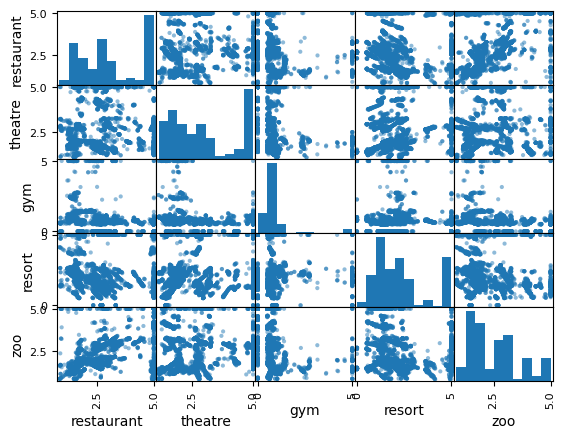

In [57]:
# add your code below
import random
import matplotlib.pyplot as plt

# Used to pick random travel categories to plot, only used once
# random_ints = []

# for i in range(0,5):
#     rand_int = -1
#     while True:
#         rand_int = random.randint(0, len(data.columns)-1)
#         if rand_int != -1 and data.columns[rand_int] not in random_ints:
#             break
#     random_ints.append(data.columns[rand_int])

pd.plotting.scatter_matrix(data[["restaurant", "theatre", "gym", "resort", "zoo"]])


# 1.2* 

What kinds of interesting relationships do you see between the pairs of dimensions you have chosen?

**Answer**: There is a positive relation between zoo and restaurants aswell as restaurants and resorts. Gym has no relation between any of the other points, as well as theaters having almost no relation. This means they have a weak relation.
- 

# 1.3*

Compute and plot the Pearson correlation coefficient matrix for all dimensions in the dataset. Remember, element $ij$ in the Pearson correlation coeffient matrix is equal to the covariance between dimension $i$ and $j$ divided by the standard deviations seen in the two dimensions. (If your numbers in the matrix are not between -1 and 1 then you have made a mistake.)

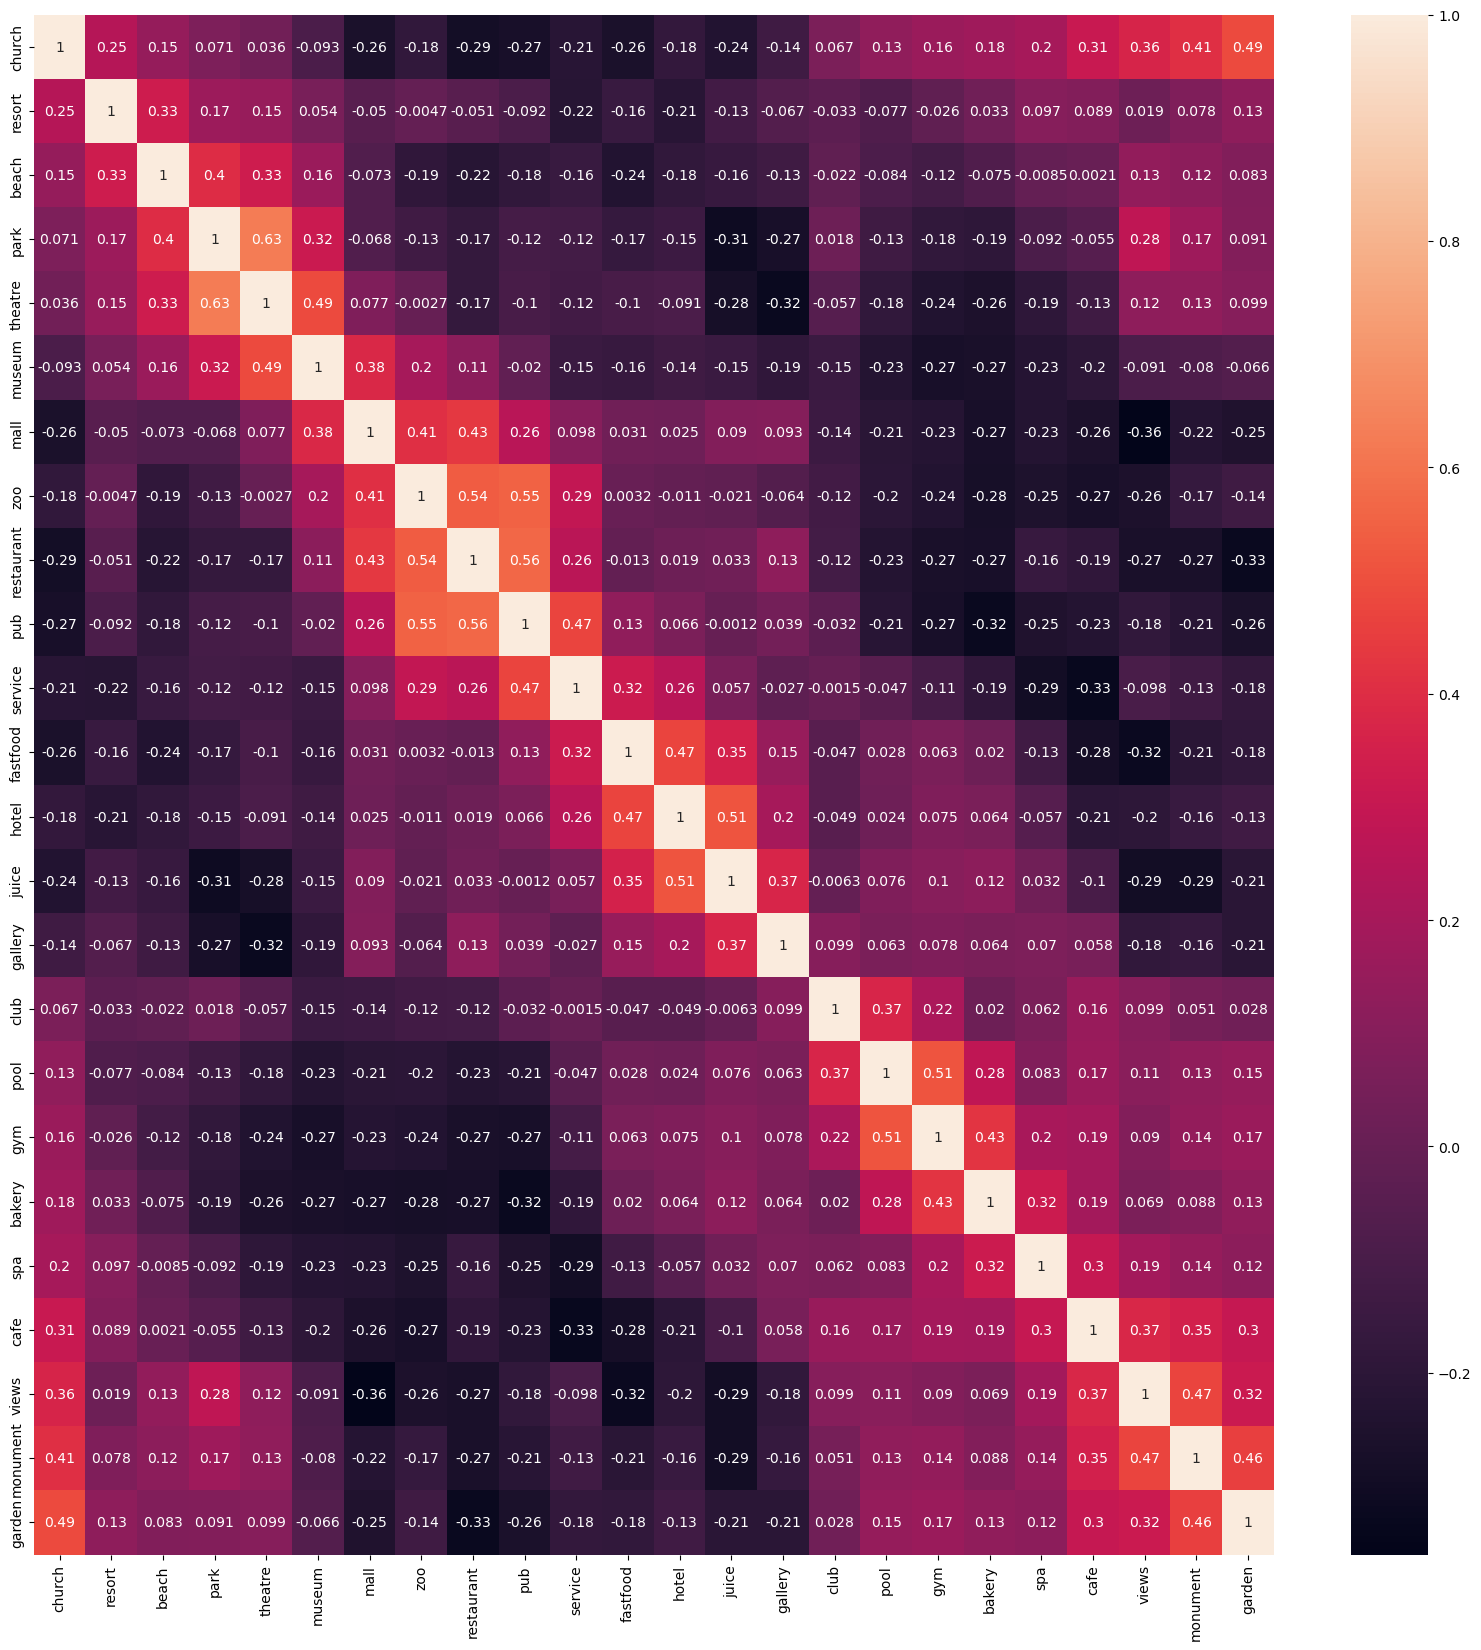

In [68]:
# add your code below
import seaborn as sns
pearson = data.corr(method='pearson')

plt.figure(figsize=(20, 20))
ax = sns.heatmap(pearson, annot=True)

# 1.4*

How do the results in 1.3 confirm your observations in 1.2? 

**Answer**: 
- 

# 1.5* 

From the results in 1.3, identify the four pairs of dimensions that have the largest magnitude correlation and make a scatter plot matrix of them.

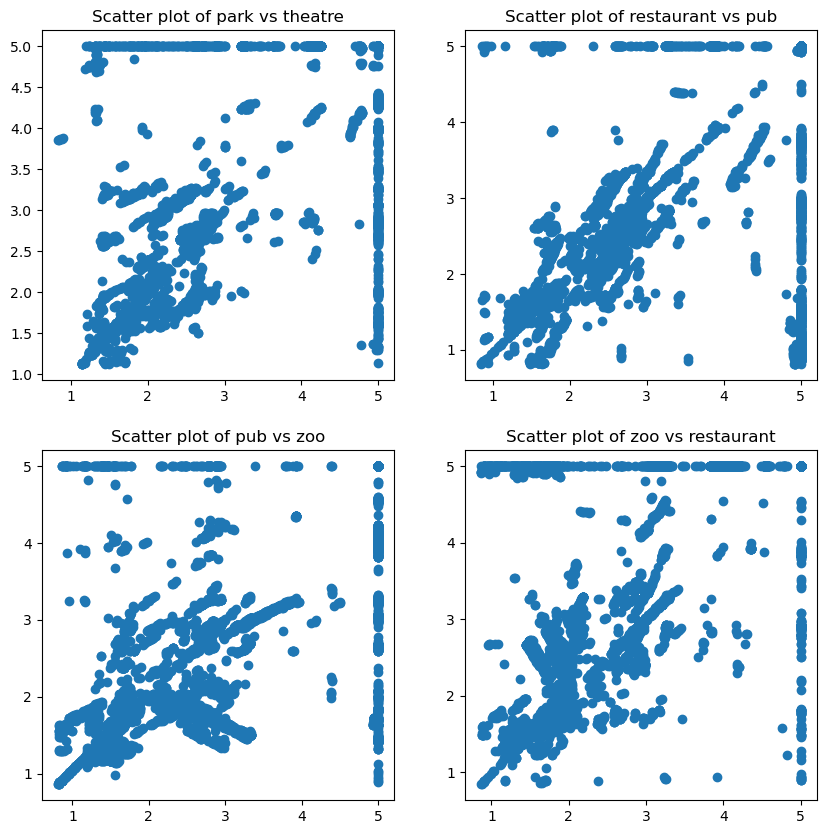

In [ ]:
# add your code below
import numpy as np
removed_diagonal = pearson.copy().abs()
np.fill_diagonal(removed_diagonal.values, np.nan)

top = removed_diagonal.unstack().sort_values(ascending=False).dropna().drop_duplicates().head(4)

fig, axes = plt.subplots(2,2,figsize=(10,10))
for ax, (i, j) in zip(axes.flatten(),top.index):
    ax.scatter(x=data[i], y=data[j])
    ax.set_title(f'Scatter plot of {i} vs {j}')

# 1.6*

From 1.4 and 1.5, try to explain why some of these dimensions may be so correlated.

**Answer**: 
- 



# 1.7* 

Compute the covariance matrix $\mathbf{C}$ of the dimensions in the dataset, and perform an eigenvector decomposition of it, $\mathbf{C} = \mathbf{Q}\mathbf{\Lambda}\mathbf{Q}^T$. Plot the eigenvalues, i.e., the diagonal elements of $\mathbf{\Lambda}$. 

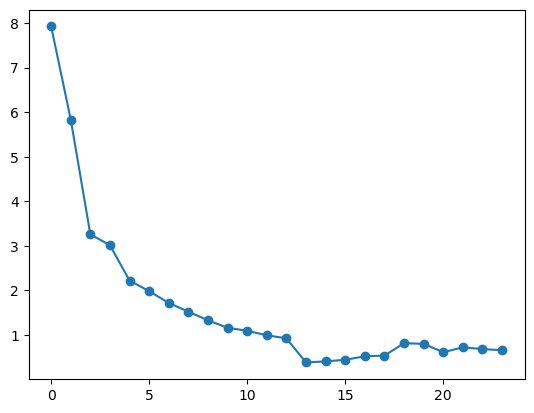

In [164]:
# add your code below
from numpy import linalg as lg
covariance = data.cov().values

eigenvalues, eigenvectors = lg.eig(covariance)

plt.figure()
plt.plot(eigenvalues, marker='o')
plt.show()


# 1.8*

Plot the two eigenvectors in $\mathbf{Q}$ having the largest eigenvalues, and label the x-axis with the appropriate dimensions.


0.9999999999999998
(24, 2)


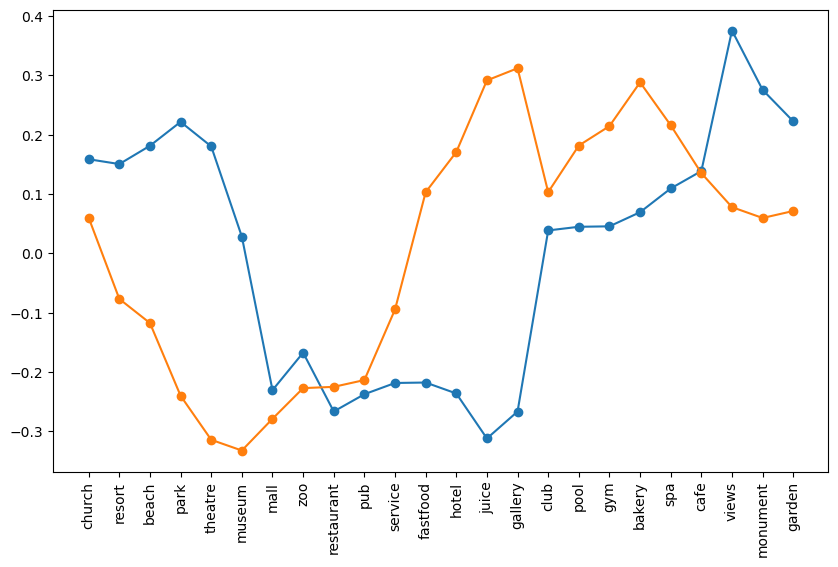

In [165]:
# add your code below

dims = data.columns
idx = np.argsort(eigenvalues)[::-1]
top2 = eigenvectors[:, idx[:2]]


plt.figure(figsize=(10, 6))
plt.xticks(rotation=90)
plt.plot(dims, top2[:, 0],marker='o', label='Eigenvector 1')
plt.plot(dims, top2[:, 1],marker='o', label='Eigenvector 2')


# 1.9*

Project the mean-centered observations of the dataset onto the two eigenvectors you found in 1.8, and make a scatter plot of the results. That is, compute the mean vector of the entire dataset $\boldsymbol{\mu}$, then for each observation $\mathbf{x}_n$ compute $\mathbf{y}_n = \mathbf{Q}^T[\mathbf{x}_n - \boldsymbol{\mu}]$, and plot a point located as the coordinates of the first two dimensions of $\mathbf{y}_n$.

On top of the scatter plot, create lines from the origin to the point $([\mathbf{q}_1]_d, [\mathbf{q}_2]_d)$ for each dimension $d$. (The notation $[\mathbf{x}]_d$ refers to the value in the $d$th dimension of $\mathbf{x}$.)

For guidance, my figure looks like this:
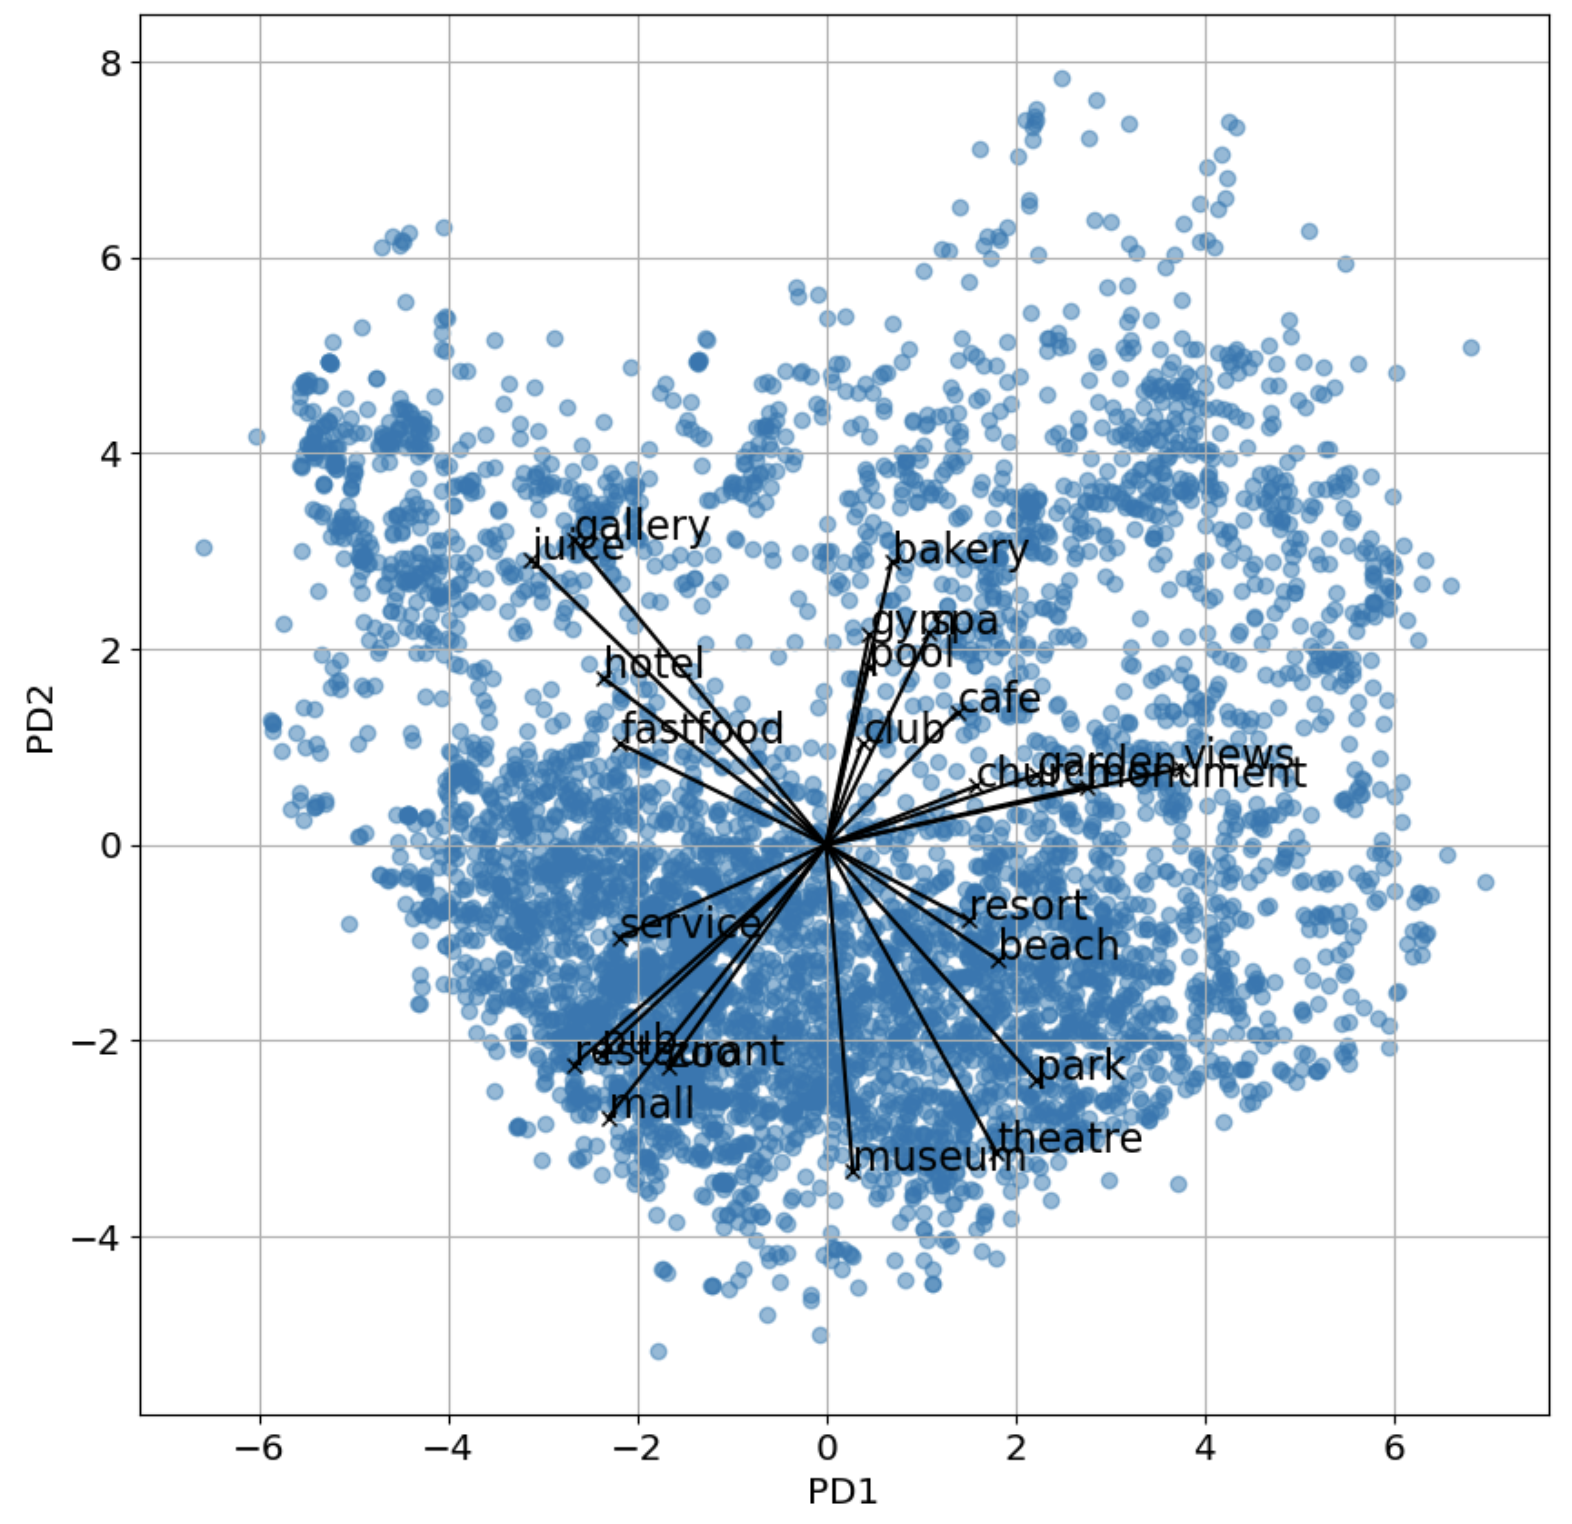

WARNING: Your figure may appear flipped, which is ok. It is just a difference in the implementation of PCA on different computer operating systems.

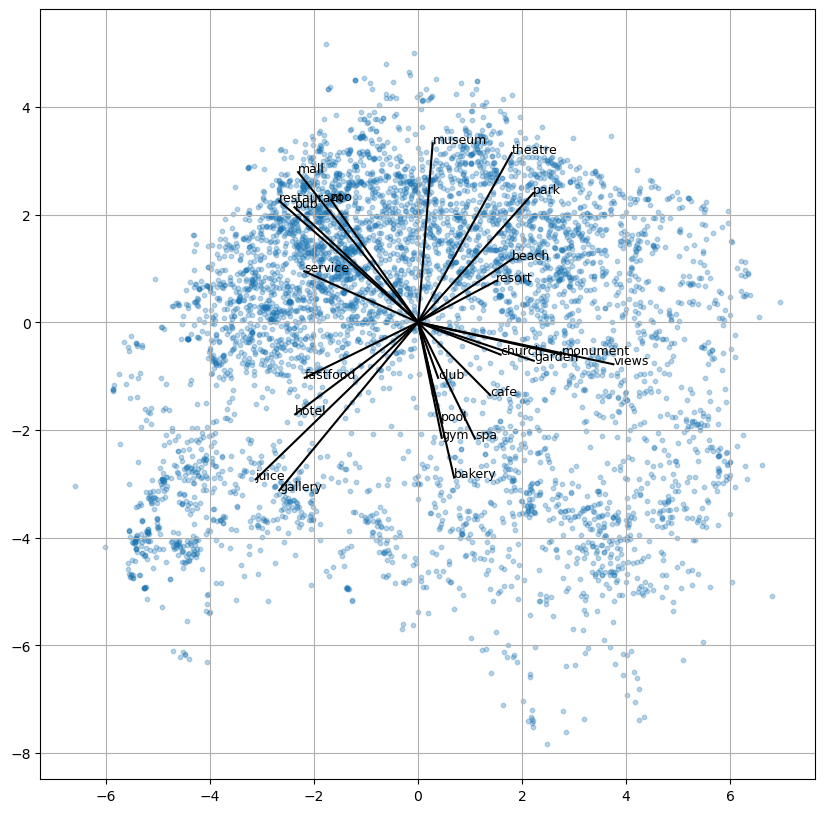

In [207]:
# add your code below

from sklearn.decomposition import PCA

pca = PCA(n_components=24)
pca_result = pca.fit_transform(data.values)

plt.figure(figsize=(10, 10))
plt.grid()

components = pca.components_.T 

for name, d in zip(data.columns.to_numpy(), range(components.shape[0])):
    x = components[d, 0]*10

    y = components[d, 1]*10
    plt.plot([0, x], [0, y], 'k-')
    plt.text(x, y, name, color='black', fontsize=9)


plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3, s=10)


# 1.10*

Find those data records with projections onto the first principal direction of between [-6,-4] and onto the second principal direction of [4,6], and plot their feature vectors on top one another. IF your picture appears flipped to mine, and you see no data records in the box specified above, then look at the points with projections onto the first principal direction of between [4,6] and between [-6,-4] onto the second principal direction.

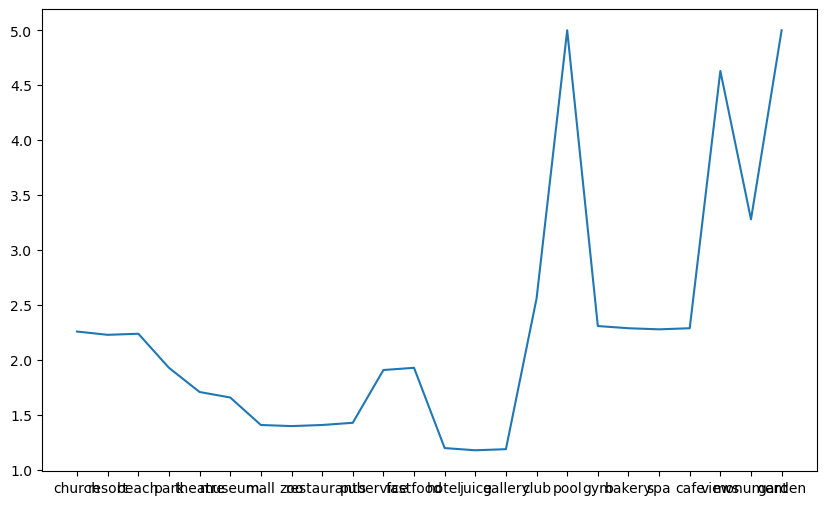

In [ ]:
# add your code below

mask = (
        (pca_result[:, 0] >= 4) & (pca_result[:, 0] <= 6) &
        (pca_result[:, 1] >= -6) & (pca_result[:, 1] <= -4)
    )

selected = data.values[mask]

plt.figure(figsize=(10, 6))
plt.plot(data.columns, selected)


# 1.11*

What can you say about the users in this part of the principal component space?

**Answer**: 

# 1.12

One thing that has been overlooked in the above is that not all users have rated all destinations. Hence some users have "0" in those dimensions, when "1" is the lowest rating possible. How can this information be taken into account in an analysis of the users contained in this dataset?

**Answer**: 